Loaded classes: ['surprised', 'neutral', 'disgust', 'fearful', 'sad', 'calm', 'happy', 'angry']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 40, 130, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 65, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 65, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,432 (29.03 KB)

 Trainable params: 7,432 (29.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.1151 - loss: 4.8258 - val_accuracy: 0.1379 - val_loss: 2.1036
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1210 - loss: 2.1167 - val_accuracy: 0.1897 - val_loss: 2.0661
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1429 - loss: 2.0696 - val_accuracy: 0.1638 - val_loss: 2.0631
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1362 - loss: 2.0630 - val_accuracy: 0.1897 - val_loss: 2.0562
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1585 - loss: 2.0620 - val_accuracy: 0.2241 - val_loss: 2.0537
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1510 - loss: 2.0602 - val_accuracy: 0.1983 - val_loss: 2.0386
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1635 - loss: 2.0402 - val_accuracy: 0.1724 - val_loss: 2.0290
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1719 - loss: 2.0387 - val_accuracy: 0.1638 - val_loss

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


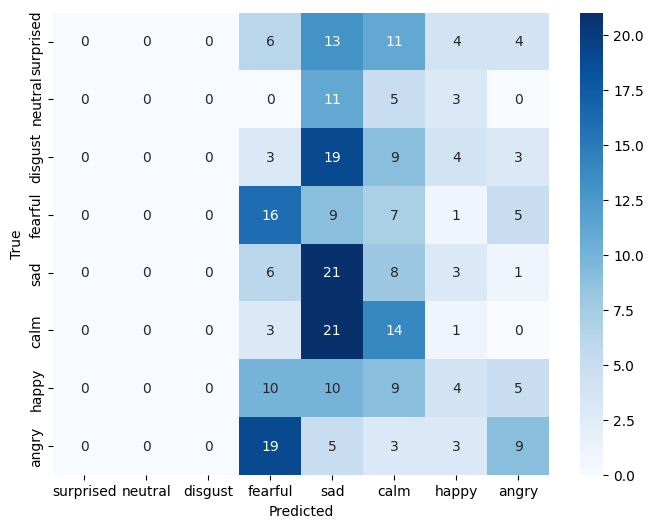

In [3]:
# 1. Setup & dependencies
!pip install -q librosa tensorflow scikit-learn

import os, glob, random, numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 2. Dataset path
DATA_ROOT = "/kaggle/input/ravdess-emotional-speech-audio"

# 3. Emotion mapping
emotion_map = {
    '01':'neutral', '02':'calm', '03':'happy', '04':'sad',
    '05':'angry', '06':'fearful', '07':'disgust', '08':'surprised'
}

# 4. Functions for emotion extraction & MFCC extraction
def extract_emotion(path):
    code = os.path.basename(path).split('-')[2]
    return emotion_map.get(code)

def extract_mfcc(path, n_mfcc=40, max_len=130):
    y, sr = librosa.load(path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0,0),(0, max_len-mfcc.shape[1])), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

# 5. Load data
files = glob.glob(os.path.join(DATA_ROOT, "Actor_*", "*.wav"), recursive=True)
X, y = [], []
emap = {}
for f in files:
    emo = extract_emotion(f)
    if emo:
        if emo not in emap:
            emap[emo] = len(emap)
        X.append(extract_mfcc(f))
        y.append(emap[emo])

X = np.array(X)[..., np.newaxis]
y = np.array(y)
labels = [e for e,_ in sorted(emap.items(), key=lambda x: x[1])]
print("Loaded classes:", labels)

# 6. Split dataset
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.1, random_state=42, stratify=y_tr)

# 7. Build simple CNN model
model = models.Sequential([
    layers.Input(X_tr.shape[1:]),
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(labels), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# 8. Train
history = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=10, batch_size=32)

# 9. Evaluate
print("\nTest Results:")
model.evaluate(X_te, y_te)

y_pred = model.predict(X_te).argmax(axis=1)
print("\nClassification Report:")
print(classification_report(y_te, y_pred, target_names=labels))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
